# A/B Testing Evaluation: KG vs KG+GA

Blinded pairwise preference survey. 4 scenarios × 3 outfit pairs = **12 forced-choice questions** per respondent. Each pair shows one KG outfit and one KG+GA outfit, with the left/right assignment randomised per the `Survey Mapping` sheet in `UserEvaluationMetrics.xlsx`.

**Goal:** decide whether adding the genetic algorithm (KG+GA) produces outfits that users prefer over the KG baseline, and whether that preference is statistically meaningful given the sample.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import binomtest

pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

EVAL_DIR = Path('..').resolve()
RESP_CSV = Path('Outfit Recommendation Evaluation (IRS_Group8).csv')
METRICS_XLSX = EVAL_DIR / 'UserEvaluationMetrics.xlsx'
print('Response CSV:', RESP_CSV.resolve())
print('Metrics XLSX:', METRICS_XLSX)

Response CSV: D:\Projects\fashion-recommender\SystemCode\services\recommender-service\eval\A_B_Testing\Response\Outfit Recommendation Evaluation (IRS_Group8).csv
Metrics XLSX: D:\Projects\fashion-recommender\SystemCode\services\recommender-service\eval\A_B_Testing\UserEvaluationMetrics.xlsx


## 1. Load survey responses and mapping

Column order in the Google Form export is Scenario 1 Pair 1..3, Scenario 2 Pair 1..3, ..., Scenario 4 Pair 1..3. We rename by position (the raw headers repeat with whitespace variations).

In [2]:
raw = pd.read_csv(RESP_CSV)
print('Raw shape:', raw.shape)

question_cols = [f'S{s}P{p}' for s in range(1, 5) for p in range(1, 4)]
assert len(raw.columns) - 1 == len(question_cols), f'Expected {len(question_cols)} question cols + 1 timestamp, got {len(raw.columns)}'

responses = raw.copy()
responses.columns = ['Timestamp'] + question_cols
responses['Timestamp'] = pd.to_datetime(responses['Timestamp'], errors='coerce')
print(f'{len(responses)} respondents')
responses.head(3)

Raw shape: (39, 13)
39 respondents


C:\Users\victo\AppData\Local\Temp\ipykernel_39040\1078629475.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  responses['Timestamp'] = pd.to_datetime(responses['Timestamp'], errors='coerce')


,Timestamp,S1P1,S1P2,S1P3,S2P1,S2P2,S2P3,S3P1,S3P2,S3P3,S4P1,S4P2,S4P3
0,2026-04-19 16:37:50-08:00,Option 2,Option 2,Option 1,Option 1,Option 2,Option 1,Option 1,Option 2,Option 2,Option 2,Option 1,Option 1
1,2026-04-19 16:49:20-08:00,Option 2,Option 2,Option 1,Option 1,Option 2,Option 1,Option 1,Option 2,Option 2,Option 2,Option 1,Option 1
2,2026-04-19 16:50:08-08:00,Option 2,Option 2,Option 1,Option 1,Option 1,Option 1,Option 1,Option 1,Option 2,Option 2,Option 1,Option 1


In [3]:
mapping = pd.read_excel(METRICS_XLSX, sheet_name='Survey Mapping')
mapping['Key'] = 'S' + mapping['Scenario'].astype(str) + 'P' + mapping['Outfit'].astype(str)
mapping = mapping.set_index('Key')[['Option 1', 'Option 2']]
mapping

,Option 1,Option 2
Key,,
S1P1,KG,KG+GA
S1P2,KG,KG+GA
S1P3,KG+GA,KG
S2P1,KG+GA,KG
S2P2,KG,KG+GA
S2P3,KG+GA,KG
S3P1,KG+GA,KG
S3P2,KG,KG+GA
S3P3,KG,KG+GA


## 2. Translate `Option 1` / `Option 2` → `KG` / `KG+GA`

This unblinds the responses. After this step each cell is either `KG` or `KG+GA`, representing the arm the respondent chose for that pair.

In [4]:
def unblind(series, key):
    opt1, opt2 = mapping.loc[key, 'Option 1'], mapping.loc[key, 'Option 2']
    return series.map({'Option 1': opt1, 'Option 2': opt2})

picks = pd.DataFrame({k: unblind(responses[k], k) for k in question_cols})
picks.insert(0, 'Timestamp', responses['Timestamp'])
picks.head(3)

,Timestamp,S1P1,S1P2,S1P3,S2P1,S2P2,S2P3,S3P1,S3P2,S3P3,S4P1,S4P2,S4P3
0,2026-04-19 16:37:50-08:00,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA
1,2026-04-19 16:49:20-08:00,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA,KG+GA
2,2026-04-19 16:50:08-08:00,KG+GA,KG+GA,KG+GA,KG+GA,KG,KG+GA,KG+GA,KG,KG+GA,KG+GA,KG+GA,KG+GA


## 3. Overall preference

Pooling all 12 questions × N respondents. A two-sided binomial test asks whether KG+GA is chosen significantly more (or less) than 50%.

In [5]:
long = picks.melt(id_vars='Timestamp', value_vars=question_cols, var_name='Question', value_name='Pick').dropna()
long['Scenario'] = long['Question'].str[1].astype(int)
long['Pair'] = long['Question'].str[3].astype(int)

totals = long['Pick'].value_counts()
n_total = int(totals.sum())
kg_ga_wins = int(totals.get('KG+GA', 0))
kg_wins = int(totals.get('KG', 0))

print(f'Total votes:       {n_total}')
print(f'KG+GA preferred:   {kg_ga_wins}  ({kg_ga_wins/n_total:.1%})')
print(f'KG preferred:      {kg_wins}  ({kg_wins/n_total:.1%})')

bt = binomtest(kg_ga_wins, n_total, p=0.5, alternative='two-sided')
print(f'\nTwo-sided binomial test vs. 50/50: p = {bt.pvalue:.4f}')
ci = bt.proportion_ci(confidence_level=0.95, method='wilson')
print(f'95% Wilson CI for KG+GA win-rate: [{ci.low:.3f}, {ci.high:.3f}]')

Total votes:       468
KG+GA preferred:   330  (70.5%)
KG preferred:      138  (29.5%)

Two-sided binomial test vs. 50/50: p = 0.0000
95% Wilson CI for KG+GA win-rate: [0.662, 0.745]


## 4. Per-scenario breakdown

In [6]:
SCENARIO_LABELS = {
    1: 'S1 Casual / Singapore / Summer',
    2: 'S2 Formal / London / Winter',
    3: 'S3 Party / Tokyo / Spring',
    4: 'S4 Sport / New York / Summer',
}

scen = (long.groupby(['Scenario', 'Pick']).size().unstack(fill_value=0))
scen = scen.reindex(columns=['KG', 'KG+GA'])
scen['Total'] = scen.sum(axis=1)
scen['KG+GA win-rate'] = scen['KG+GA'] / scen['Total']
scen['p (two-sided)'] = [binomtest(int(r['KG+GA']), int(r['Total']), 0.5).pvalue for _, r in scen.iterrows()]
scen.index = [SCENARIO_LABELS[i] for i in scen.index]
scen

Pick,KG,KG+GA,Total,KG+GA win-rate,p (two-sided)
S1 Casual / Singapore / Summer,20,97,117,0.829,0.000
S2 Formal / London / Winter,48,69,117,0.590,0.064
S3 Party / Tokyo / Spring,35,82,117,0.701,0.000
S4 Sport / New York / Summer,35,82,117,0.701,0.000


## 5. Per outfit-pair breakdown

Each pair pits one specific KG outfit against one specific KG+GA outfit. This is the finest-grained view.

In [7]:
pair = (long.groupby(['Scenario', 'Pair', 'Pick']).size().unstack(fill_value=0))
pair = pair.reindex(columns=['KG', 'KG+GA'])
pair['Total'] = pair.sum(axis=1)
pair['KG+GA win-rate'] = pair['KG+GA'] / pair['Total']
pair['p (two-sided)'] = [binomtest(int(r['KG+GA']), int(r['Total']), 0.5).pvalue for _, r in pair.iterrows()]
pair

Pick           KG  KG+GA  Total  KG+GA win-rate  p (two-sided)
Scenario Pair                                                 
1        1      4     35     39           0.897          0.000
         2     12     27     39           0.692          0.024
         3      4     35     39           0.897          0.000
2        1      6     33     39           0.846          0.000
         2     20     19     39           0.487          1.000
         3     22     17     39           0.436          0.522
3        1     23     16     39           0.410          0.337
         2      9     30     39           0.769          0.001
         3      3     36     39           0.923          0.000
4        1     11     28     39           0.718          0.009
         2     11     28     39           0.718          0.009
         3     13     26     39           0.667          0.053

## 6. Visualisations

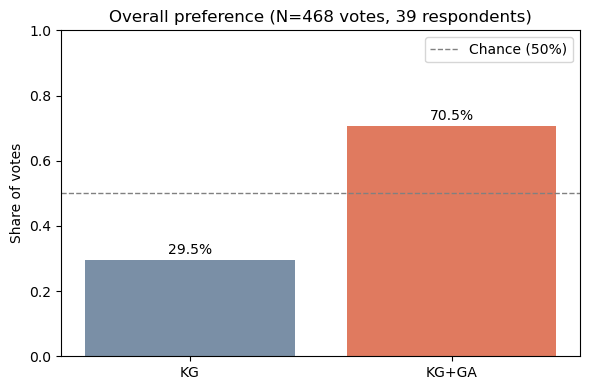

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
rates = {'KG': kg_wins / n_total, 'KG+GA': kg_ga_wins / n_total}
bars = ax.bar(rates.keys(), rates.values(), color=['#7a8fa6', '#e07a5f'])
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Chance (50%)')
ax.set_ylim(0, 1)
ax.set_ylabel('Share of votes')
ax.set_title(f'Overall preference (N={n_total} votes, {len(responses)} respondents)')
for b, v in zip(bars, rates.values()):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.1%}', ha='center')
ax.legend()
plt.tight_layout(); plt.show()

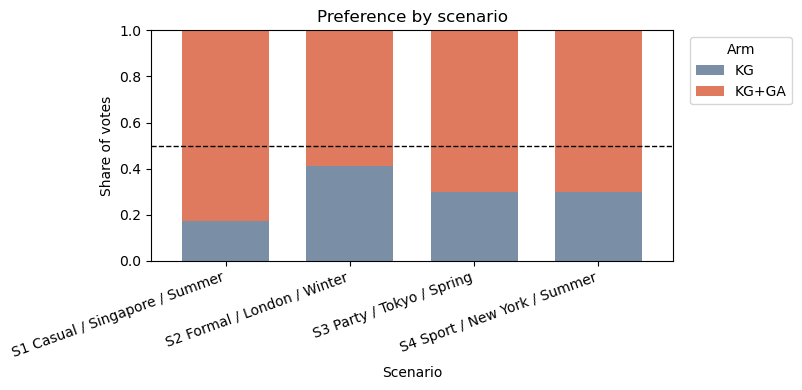

In [9]:
scen_plot = (long.groupby(['Scenario', 'Pick']).size().unstack(fill_value=0)).reindex(columns=['KG', 'KG+GA'])
scen_plot_pct = scen_plot.div(scen_plot.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
scen_plot_pct.plot(kind='bar', stacked=True, ax=ax, color=['#7a8fa6', '#e07a5f'], width=0.7)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_xticklabels([SCENARIO_LABELS[i] for i in scen_plot_pct.index], rotation=20, ha='right')
ax.set_ylabel('Share of votes')
ax.set_title('Preference by scenario')
ax.legend(title='Arm', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

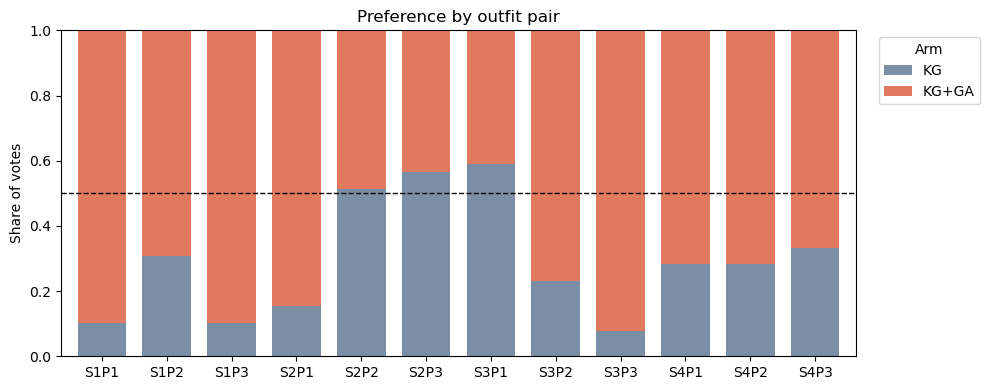

In [10]:
pair_plot = (long.groupby(['Scenario', 'Pair', 'Pick']).size().unstack(fill_value=0)).reindex(columns=['KG', 'KG+GA'])
pair_plot_pct = pair_plot.div(pair_plot.sum(axis=1), axis=0)
pair_plot_pct.index = [f'S{s}P{p}' for s, p in pair_plot_pct.index]

fig, ax = plt.subplots(figsize=(10, 4))
pair_plot_pct.plot(kind='bar', stacked=True, ax=ax, color=['#7a8fa6', '#e07a5f'], width=0.75)
ax.axhline(0.5, color='black', linestyle='--', linewidth=1)
ax.set_ylabel('Share of votes')
ax.set_title('Preference by outfit pair')
ax.legend(title='Arm', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 7. Cross-reference: preference vs. dead-stock & price

KG+GA deliberately surfaces dead-stock items (it is a GA fitness objective). Does preferring KG+GA trend with the dead-stock count or price of the outfit pair?

In [11]:
kg = pd.read_excel(METRICS_XLSX, sheet_name='KG')
kgga = pd.read_excel(METRICS_XLSX, sheet_name='KG+GA')
kg['Arm'] = 'KG'; kgga['Arm'] = 'KG+GA'
metrics = pd.concat([kg, kgga], ignore_index=True)
metrics_wide = metrics.pivot_table(index=['Scenario', 'Outfit'], columns='Arm', values=['Total Dead stock', 'Total Price'])
metrics_wide.columns = [f'{v}__{a}' for v, a in metrics_wide.columns]
metrics_wide = metrics_wide.reset_index()
metrics_wide['DeadStockDiff (GA-KG)'] = metrics_wide['Total Dead stock__KG+GA'] - metrics_wide['Total Dead stock__KG']
metrics_wide['PriceDiff (GA-KG)'] = metrics_wide['Total Price__KG+GA'] - metrics_wide['Total Price__KG']
metrics_wide

,Scenario,Outfit,Total Dead stock__KG,Total Dead stock__KG+GA,Total Price__KG,Total Price__KG+GA,DeadStockDiff (GA-KG),PriceDiff (GA-KG)
0,1,1,0.000,1.000,32.970,57.530,1.000,24.560
1,1,2,0.000,0.000,123.860,50.700,0.000,-73.160
2,1,3,0.000,1.000,139.880,56.190,1.000,-83.690
3,2,1,0.000,1.000,105.580,103.190,1.000,-2.390
4,2,2,0.000,1.000,227.790,138.420,1.000,-89.370
5,2,3,0.000,0.000,163.340,86.320,0.000,-77.020
6,3,1,0.000,0.000,191.290,73.920,0.000,-117.370
7,3,2,0.000,0.000,125.600,49.490,0.000,-76.110
8,3,3,0.000,0.000,70.220,87.240,0.000,17.020
9,4,1,0.000,0.000,128.320,41.090,0.000,-87.230


In [12]:
pair_rates = pair.reset_index()[['Scenario', 'Pair', 'KG+GA win-rate']].rename(columns={'Pair': 'Outfit', 'KG+GA win-rate': 'KG+GA_winrate'})
joined = metrics_wide.merge(pair_rates, on=['Scenario', 'Outfit'])
joined[['Scenario', 'Outfit', 'KG+GA_winrate', 'DeadStockDiff (GA-KG)', 'PriceDiff (GA-KG)']]

,Scenario,Outfit,KG+GA_winrate,DeadStockDiff (GA-KG),PriceDiff (GA-KG)
0,1,1,0.897,1.000,24.560
1,1,2,0.692,0.000,-73.160
2,1,3,0.897,1.000,-83.690
3,2,1,0.846,1.000,-2.390
4,2,2,0.487,1.000,-89.370
5,2,3,0.436,0.000,-77.020
6,3,1,0.410,0.000,-117.370
7,3,2,0.769,0.000,-76.110
8,3,3,0.923,0.000,17.020
9,4,1,0.718,0.000,-87.230


In [13]:
print('Pearson correlation with KG+GA win-rate:')
print(joined[['KG+GA_winrate', 'DeadStockDiff (GA-KG)', 'PriceDiff (GA-KG)']].corr()['KG+GA_winrate'])

Pearson correlation with KG+GA win-rate:
KG+GA_winrate           1.000
DeadStockDiff (GA-KG)   0.265
PriceDiff (GA-KG)       0.670
Name: KG+GA_winrate, dtype: float64


## 8. Summary

- Section 3 reports whether users prefer KG+GA overall (point estimate, 95% CI, p-value).
- Section 4 shows whether the preference holds across all four scenarios or is concentrated in specific occasions.
- Section 5 surfaces individual outfit pairs where the GA wins or loses decisively — useful for qualitative review of the images.
- Section 7 tests whether preference trades off against dead-stock inclusion: a negative correlation between `KG+GA_winrate` and `DeadStockDiff` would indicate users penalise outfits with more dead-stock items; a near-zero correlation means the GA's clearance goal is not hurting user perception.